# Chapter 12 Reproduction — Deploying Machine Learning Models
This notebook reproduces the main workflow from Chapter 12 using the provided `diabetes.csv`: load → clean → correlation → select features → compare algorithms with 10-fold cross-validation → train/save → Flask deployment pattern.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import pickle

df = pd.read_csv('diabetes.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Clean zero values as Chapter 12 does
Pregnancies and Outcome may legitimately be zero. For Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction and Age, Chapter 12 treats zero as missing and replaces it with the column mean.

In [2]:
columns = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
print('Nulls before:', df.isnull().sum())
print('Zeros before:', df.eq(0).sum())
df[columns] = df[columns].replace(0, np.nan)
df.fillna(df.mean(numeric_only=True), inplace=True)
print('Zeros after:', df.eq(0).sum())

Nulls before: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Zeros before: Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64
Zeros after: Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


## Correlation and selected features
Chapter 12 identifies `Glucose`, `BMI` and `Age` as the three strongest non-target correlations with Outcome.

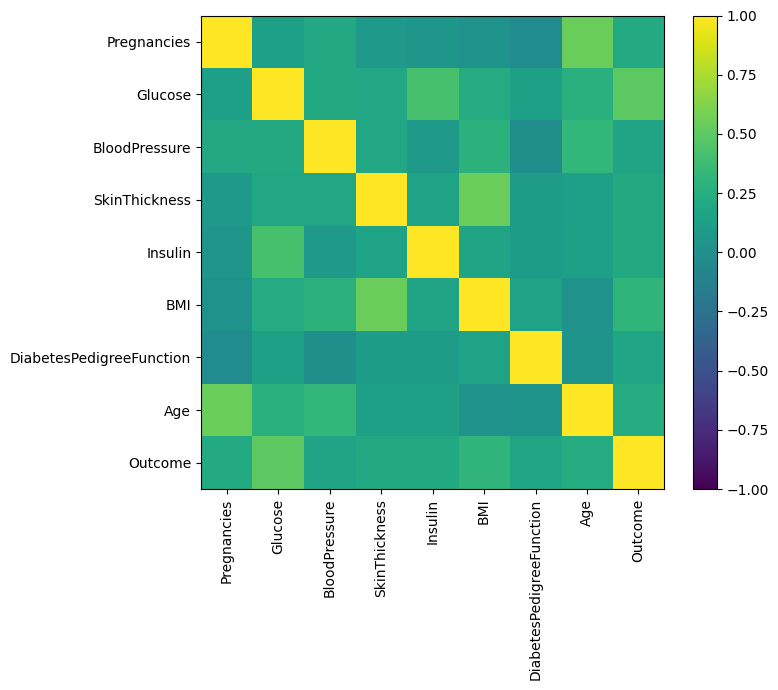

Outcome    1.000000
Glucose    0.492928
BMI        0.311924
Age        0.238356
Name: Outcome, dtype: float64


In [3]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,7))
plt.imshow(corr, vmin=-1, vmax=1, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout(); plt.show()
print(df.corr(numeric_only=True).nlargest(4,'Outcome')['Outcome'])
X = df[['Glucose','BMI','Age']]
y = df['Outcome']

## Evaluate the algorithms with 10-fold cross-validation
The book compares Logistic Regression, KNN, SVM Linear and SVM RBF. The RBF example below uses `gamma='auto'` to reproduce the older scikit-learn default/results used by the 2019 book.

In [4]:
results = {}
log_reg = LogisticRegression(max_iter=1000)
results['Logistic Regression'] = cross_val_score(log_reg, X, y, cv=10, scoring='accuracy').mean()

ks = list(range(1, 50, 2))
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y, cv=10, scoring='accuracy').mean() for k in ks]
optimal_k = ks[int(np.argmax(cv_scores))]
results['K Nearest Neighbors'] = max(cv_scores)

results['SVM Linear Kernel'] = cross_val_score(SVC(kernel='linear'), X, y, cv=10, scoring='accuracy').mean()
results['SVM RBF Kernel'] = cross_val_score(SVC(kernel='rbf', gamma='auto'), X, y, cv=10, scoring='accuracy').mean()
print('Optimal k:', optimal_k)
display(pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy']).sort_values('Accuracy',ascending=False))

Optimal k: 19


,Accuracy
K Nearest Neighbors,0.772146
Logistic Regression,0.766986
SVM Linear Kernel,0.765653
SVM RBF Kernel,0.635373


Expected with this file: KNN is best at approximately **0.7721 accuracy** with **k = 19**, matching Chapter 12.

In [5]:
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X,y)
filename='diabetes.sav'
pickle.dump(knn, open(filename,'wb'))
loaded_model=pickle.load(open(filename,'rb'))
Glucose=65; BMI=70; Age=50
pred=loaded_model.predict([[Glucose,BMI,Age]])
proba=loaded_model.predict_proba([[Glucose,BMI,Age]])
print('Prediction:', pred[0])
print('Confidence:', round(np.amax(proba[0])*100,2),'%')

Prediction: 0
Confidence: 94.74 %


/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Flask deployment pattern from Chapter 12
The house-price project applies the same idea in `app.py`: load the persisted model, receive input, create the correct feature representation, call `predict()`, and return the result to a web/mobile client.